In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [6]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [7]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [8]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [9]:
df.shape

(270, 14)

In [10]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [12]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [13]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

Age                         41
Sex                          2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
Heart Disease                2
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

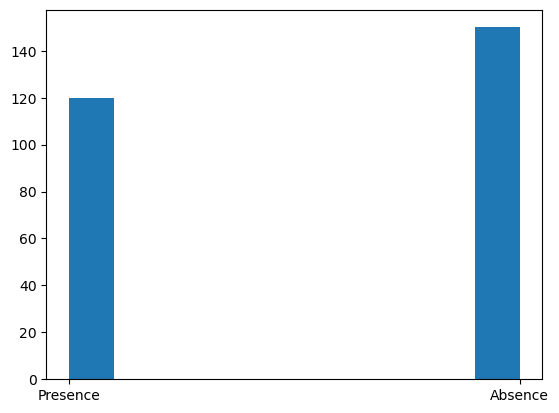

In [16]:
plt.hist(df['Heart Disease'])
plt.show

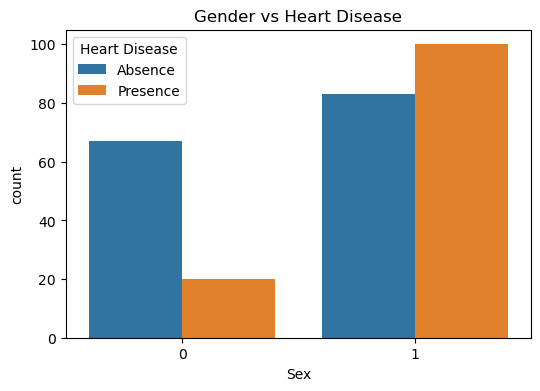

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Heart Disease")
plt.title("Gender vs Heart Disease")
plt.show()

<Axes: xlabel='Chest pain type', ylabel='count'>

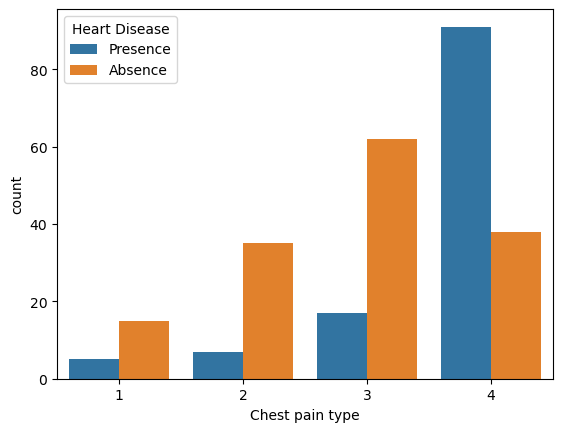

In [18]:
sns.countplot(
    data=df,
    x="Chest pain type",
    hue="Heart Disease"
)

In [19]:
corr_df = df.copy()
le = LabelEncoder()
corr_df["Heart Disease"]=le.fit_transform(corr_df["Heart Disease"])
print(le.classes_)

['Absence' 'Presence']


In [20]:
corr_mat = corr_df.corr()
print(corr_mat)

                              Age       Sex  Chest pain type        BP  \
Age                      1.000000 -0.094401         0.096920  0.273053   
Sex                     -0.094401  1.000000         0.034636 -0.062693   
Chest pain type          0.096920  0.034636         1.000000 -0.043196   
BP                       0.273053 -0.062693        -0.043196  1.000000   
Cholesterol              0.220056 -0.201647         0.090465  0.173019   
FBS over 120             0.123458  0.042140        -0.098537  0.155681   
EKG results              0.128171  0.039253         0.074325  0.116157   
Max HR                  -0.402215 -0.076101        -0.317682 -0.039136   
Exercise angina          0.098297  0.180022         0.353160  0.082793   
ST depression            0.194234  0.097412         0.167244  0.222800   
Slope of ST              0.159774  0.050545         0.136900  0.142472   
Number of vessels fluro  0.356081  0.086830         0.225890  0.085697   
Thallium                 0.106100  0.3

<Axes: >

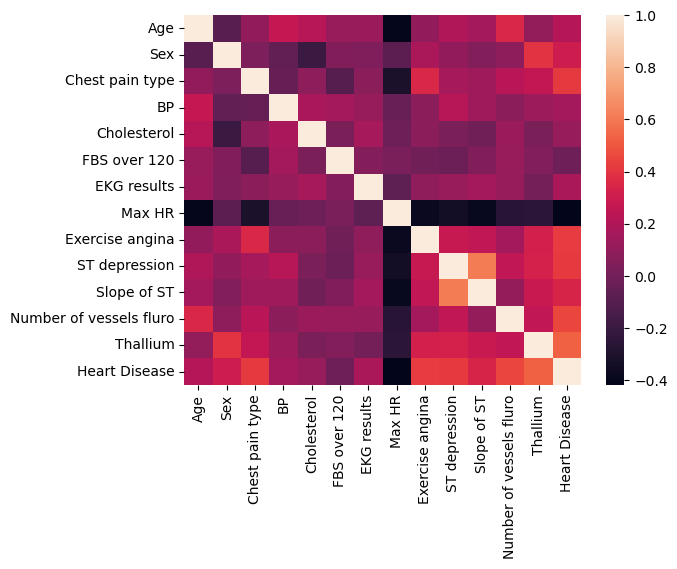

In [21]:
sns.heatmap(corr_mat)

<Axes: xlabel='Age'>

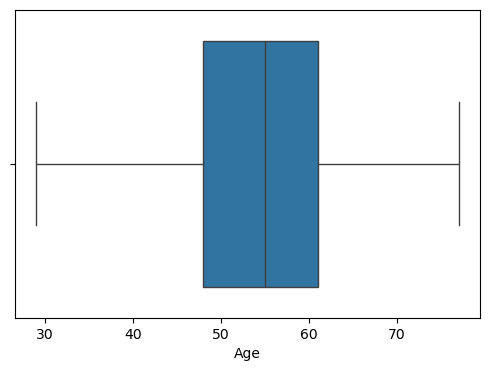

In [22]:
#plt.boxplot(df["Age"])
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Age")

In [23]:
le_target = LabelEncoder()
df["Heart Disease"] = le_target.fit_transform(df["Heart Disease"])

In [24]:
X = df.drop("Heart Disease", axis=1)
y= df["Heart Disease"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
model = RandomForestClassifier( random_state =42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

comparison.head(10)

,actual,predicted
30,1,0
116,1,1
79,0,0
127,0,0
196,0,0
137,1,1
209,0,1
45,0,0
158,0,0
247,0,0


In [28]:
print("accuracy = ",accuracy_score(y_test,y_pred))

accuracy =  0.7962962962962963


In [29]:
print(confusion_matrix(y_test,y_pred))

[[29  4]
 [ 7 14]]


In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54



In [31]:
# HYPERPARAMETER TUNING 

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid= param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [34]:
grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)
model_best = grid.best_estimator_
y_pred_best = model_best.predict(X_test)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
0.7989473684210526


In [37]:
print(accuracy_score(y_test,y_pred_best))

0.8518518518518519


In [39]:
print(model_best.feature_importances_)

[0.07219623 0.02259458 0.14487696 0.06858292 0.08034106 0.00541173
 0.01288093 0.10483974 0.06547632 0.15404867 0.05721173 0.08840541
 0.12313373]


In [48]:
joblib.dump(model_best,"heart_disease_model.pkl")

['heart_disease_model.pkl']

In [49]:
joblib.dump(le_target,"label_encoder.pkl")

['label_encoder.pkl']

In [50]:
joblib.dump(grid.best_params_, "best_params.pkl")
metrics = {
    "accuracy": accuracy_score(y_test, y_pred_best),
    "recall": recall_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best),
    "f1": f1_score(y_test, y_pred_best),
}

joblib.dump(metrics, "metrics.pkl")

['metrics.pkl']